## COMP 6934 Winter 2026 Credit Problem 13X

Plotly Graph Objects.

Use the improved data set weather.zip


In [56]:
import plotly.graph_objects as go
import pandas as pd

In [57]:
# Cleaning up missing temp, rainfall (precipitation) and one record per day
nlWeather = pd.read_csv('datasets/jash312i/NL_weather.csv')
nlWeather.dropna(subset=["Mean Temp (C)"], inplace=True)
nlWeather.drop_duplicates(subset=["Station Name", "Date/Time"], inplace=True)
nlWeather['Total Precip (mm)'] = nlWeather['Total Precip (mm)'].fillna(0)
nlWeather['Date/Time'] = pd.to_datetime(nlWeather['Date/Time'])
nlWeather.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87648 entries, 1 to 99656
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Longitude (x)              87648 non-null  float64       
 1   Latitude (y)               87648 non-null  float64       
 2   Station Name               87648 non-null  object        
 3   Climate ID                 87648 non-null  object        
 4   Date/Time                  87648 non-null  datetime64[ns]
 5   Year                       87648 non-null  int64         
 6   Month                      87648 non-null  int64         
 7   Day                        87648 non-null  int64         
 8   Data Quality               0 non-null      float64       
 9   Max Temp (C)               87648 non-null  float64       
 10  Max Temp Flag              42 non-null     object        
 11  Min Temp (C)               87648 non-null  float64       
 12  Min Temp 

C:\Users\abstr\AppData\Local\Temp\ipykernel_23648\827488151.py:2: DtypeWarning:

Columns (3,20,22,26,29) have mixed types. Specify dtype option on import or set low_memory=False.



In [58]:
sjWeather = nlWeather[nlWeather['Station Name'].str.contains("ST. JOHN'S INTL") & (nlWeather['Year'] == 2020)]
sjWeather.info()

<class 'pandas.core.frame.DataFrame'>
Index: 361 entries, 52936 to 53301
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Longitude (x)              361 non-null    float64       
 1   Latitude (y)               361 non-null    float64       
 2   Station Name               361 non-null    object        
 3   Climate ID                 361 non-null    object        
 4   Date/Time                  361 non-null    datetime64[ns]
 5   Year                       361 non-null    int64         
 6   Month                      361 non-null    int64         
 7   Day                        361 non-null    int64         
 8   Data Quality               0 non-null      float64       
 9   Max Temp (C)               361 non-null    float64       
 10  Max Temp Flag              0 non-null      object        
 11  Min Temp (C)               361 non-null    float64       
 12  Min Tem

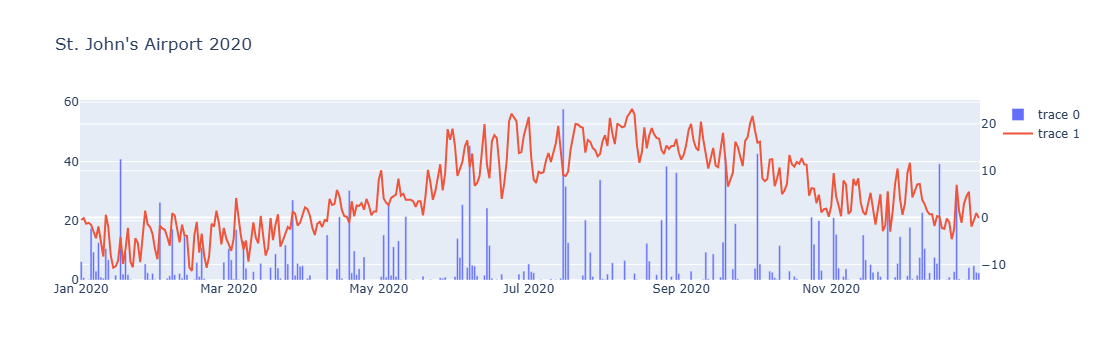

In [59]:
# make a go plot with go class methods

fig1 = go.Figure(
    [go.Bar(
        x= sjWeather['Date/Time'],
        y= sjWeather['Total Precip (mm)'],
        yaxis = 'y1'
    ),
     go.Scatter(
        x= sjWeather['Date/Time'],
        y= sjWeather['Mean Temp (C)'],
        mode='lines' ,
        yaxis = 'y2'
     )
    ],
    go.Layout(
        title="St. John's Airport 2020",
        yaxis1=dict(side='left'),
        yaxis2=dict(side='right', overlaying='y')
        
    )
)
fig1

### Monthly precipitation

The bar graphs do not look useful with daily values, so I am going to aggregate them by month.

In [89]:
sjgb = sjWeather[["Date/Time", "Month", "Total Precip (mm)"]].groupby(by="Month")
sjMonthly = sjgb.agg({"Date/Time" : "last", "Total Precip (mm)": "sum"})
sjMonthly.info

<bound method DataFrame.info of        Date/Time  Total Precip (mm)
Month                              
1     2020-01-31              134.8
2     2020-02-29               91.4
3     2020-03-31              139.0
4     2020-04-30               98.9
5     2020-05-31               96.0
6     2020-06-30              154.1
7     2020-07-31              180.4
8     2020-08-31              135.8
9     2020-09-30              100.1
10    2020-10-31              131.3
11    2020-11-30              130.9
12    2020-12-31              165.8>

In [90]:
# To align the montly values to appear on the same x-axis as daily temperature, I am setting the x-value to the middle of the month.
# Unforturnately, this will give an incorrect day on the plotly graph "scrollover" display.
# There should be a way to calculate an offset to line up the two types of x-values (daily and monthly), but I was unable to find a simple
# way to do this, and there is already enough data fiddling in this problem set.

sjMonthly["Date/Offset"] = sjMonthly["Date/Time"] - pd.Timedelta(15, "days")

In [91]:
sjMonthly


,Date/Time,Total Precip (mm),Date/Offset
Month,,,
1,2020-01-31,134.8,2020-01-16
2,2020-02-29,91.4,2020-02-14
3,2020-03-31,139.0,2020-03-16
4,2020-04-30,98.9,2020-04-15
5,2020-05-31,96.0,2020-05-16
6,2020-06-30,154.1,2020-06-15
7,2020-07-31,180.4,2020-07-16
8,2020-08-31,135.8,2020-08-16
9,2020-09-30,100.1,2020-09-15


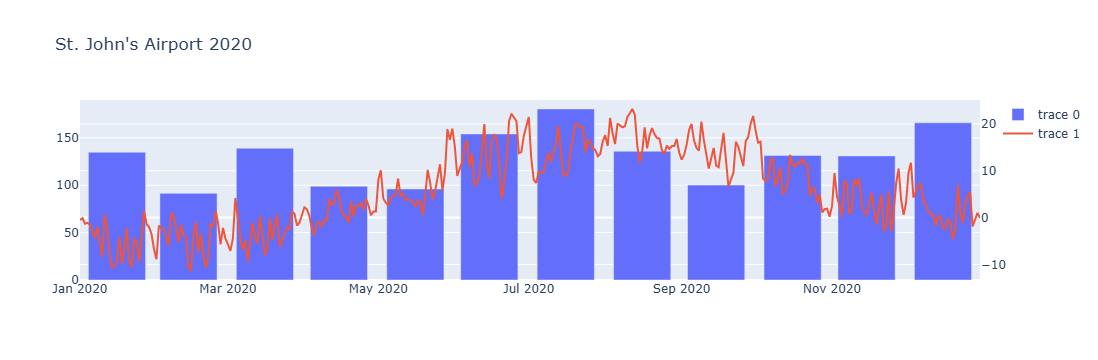

In [92]:
# make a go plot with go class methods

fig2 = go.Figure(
    [go.Bar(
        x= sjMonthly['Date/Offset'],
        y= sjMonthly['Total Precip (mm)'],
        yaxis = 'y1'
    ),
     go.Scatter(
        x= sjWeather['Date/Time'],
        y= sjWeather['Mean Temp (C)'],
        mode='lines' ,
        yaxis = 'y2'
     )
    ],
    go.Layout(
        title="St. John's Airport 2020",
        yaxis1=dict(side='left'),
        yaxis2=dict(side='right', overlaying='y')
        
    )
)
fig2

### Problem Set 13X

Exploring traces and axes in plotly graph objects 


### Problem 13.1

 Add traces for Toronto and Vancouver temperature to the plot. (One station from each city for the year 2020)

### Problem 13.2

Add traces for Vancouver and Toronto rainfall to the plot. Choose a design for the combined histogram (stacked is probably NOT best, as rainfall from three different locations does not accumulate together).

### Problem 13.3

Make appropriate text labels on the graph, all three axes, and the legend.

### Problem 13.4

The grid lines for the two y-axes are different, which makes the background confusing. The grid lines for the left y-axis have a different spacing than the grid lines for the right y-axis.

Pick limits for the two y-axes so one scale range is a multiple of the other scale range, which should cause the grid lines to overlap, and therfore look less less confusing. Implement these axis limits on the plot.



# Attributions

Be sure to add your own sources or indicate you have none to add.  Sources can be web sites, text materials, and so on. They do not have to be hyperlinks. Other people are also sources, but they are not allowed for in class credit problems.

| Source | What is it | How used |
|--|--|--|
| <https://www.kaggle.com/datasets/jash312/canada-daily-weather-data-from-2018-to-2023> | data sets | taken directly as csv files  |